In [1]:
import os
# The jupyter notebook is launched from your $HOME directory.
# Change the working directory to your username directory under /scratch/cd82
os.chdir(os.path.expandvars("/scratch/cd82/$USER/"))

# Image Classification with Convolutional Neural Networks

## Episode 04 Compile and Train (Fit) a Convolutional Neural Network


In [2]:
# load the required packages
from tensorflow import keras # data and neural network
from sklearn.model_selection import train_test_split # data splitting
import matplotlib.pyplot as plt # plotting
import seaborn as sns # specialised plotting
import pandas as pd # handles dataframes

2025-08-20 10:04:35.375655: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-20 10:04:35.381618: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 10:04:35.450858: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 10:04:35.452834: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-20 10:04:36.909111: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [3]:
# function to prepare the training dataset
def prepare_dataset(train_images, train_labels):
    
    # normalize the RGB values to be between 0 and 1
    train_images = train_images / 255
    
    # one hot encode the training labels
    train_labels = keras.utils.to_categorical(train_labels, len(class_names))
    
    # split the training data into training and validation set
    train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size = 0.2, random_state=42)

    return train_images, val_images, train_labels, val_labels

In [4]:
# function to define the introduction model
def create_model_intro():

    inputs_intro = keras.Input(shape=train_images.shape[1:]) # INPUT LAYER
    
    x_intro = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu')(inputs_intro) # Layer 1
    x_intro = keras.layers.MaxPooling2D(pool_size=(2,2))(x_intro) # Layer 2
    x_intro = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')(x_intro) # Layer 3
    x_intro = keras.layers.MaxPooling2D(pool_size=(2,2))(x_intro) # Layer 4
    x_intro = keras.layers.Flatten()(x_intro) # Layer 5
    x_intro = keras.layers.Dense(units=64, activation='relu')(x_intro) # Layer 6
    
    outputs_intro = keras.layers.Dense(units=10, activation='softmax')(x_intro) # OUTPUT LAYER
    
    # create the model
    model_intro = keras.Model(inputs = inputs_intro, 
                              outputs = outputs_intro, 
                              name = "cifar_model_intro")
    
    return model_intro

In [5]:
# load the data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# create a list of classnames
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# prepare the dataset for training
train_images, val_images, train_labels, val_labels = prepare_dataset(train_images, train_labels)

In [6]:
# create the introduction model
model_intro = create_model_intro()

# view model summary
model_intro.summary()

2025-08-20 10:05:26.193237: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "cifar_model_intro"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 16)        448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 32)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1152)        

## Step 5. Choose a loss function and optimizer and compile model

We now need to compile the model, or set up the rules and strategies for how the network will learn. To do this, we select an appropriate loss function and optimizer to use during training (fitting).

[Keras Model training APIs](https://keras.io/api/models/model_training_apis/)

### Optimizer

An optimizer is the algorithm with which the model learns to optimize on the provided loss function, or minimise the model error.

Here we picked one of the most common optimizers demonstrated to work well for most tasks, the **Adam** optimizer, as our starting point.

### Loss function

The purpose of loss functions is to compute the quantity that a model should seek to minimize during training.

Here we chose **CategoricalCrossentropy** because we want to compute the difference between our one-hot encoded class labels and the model predictions and this loss function is appropriate when the data has two or more label classes.

### Metrics

A metric is a function used to judge the performance of the model.

Typically, for classification problems, you will use **CategoricalAccuracy**, which calculates how often the model predictions match the true labels,

## CHALLENGE Write the code to compile the introductory model

Use the Model.compile() function to compile the model_intro.

Hint 1: Use ‘Adam’ for the optimizer.

Hint 2: Use ‘CategoricalCrossentropy’ for the loss.

Hint 3: Use ‘CategoricalAccuracy’ as the metric.

In [ ]:
# # compile the model
# _____.compile(optimizer = _____, 
#                     loss = _____, 
#                     metrics = _____)

In [7]:
# SOLUTION
model_intro.compile(optimizer = keras.optimizers.Adam(),
                    loss = keras.losses.CategoricalCrossentropy(),
                    metrics = keras.metrics.CategoricalAccuracy())

## Step 6. Train (Fit) model

Training a model means teaching the computer to recognize patterns in data by adjusting its internal parameters, or iteratively comparing its predictions with the actual outcomes to minimize errors.


## CHALLENGE Write the code to fit the introductory model

Use the Model.fit function to train (fit) the model_intro.

Hint 1: Use a batch size of 32.

Hint 2: Train for 10 epochs.

Hint 3: Use a tuple of the form (x_val, y_val) and our validation dataset variable names.

Hint 4: Store the training loss and metrics in a variable call ‘history_intro’

In [ ]:
# # fit the model
# _____ = _____.fit(x = _____, y = _____,
#                                 batch_size = _____,
#                                 epochs = _____, 
#                                 validation_data = (_____, _____))

In [8]:
# SOLUTION
# fit model
history_intro = model_intro.fit(x = train_images, y = train_labels,
                                batch_size = 32,
                                epochs = 10, 
                                validation_data = (val_images, val_labels))

Epoch 1/10
1250/1250 [==============================] - 8s 6ms/step - loss: 1.5816 - categorical_accuracy: 0.4246 - val_loss: 1.4023 - val_categorical_accuracy: 0.5039
Epoch 2/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.2844 - categorical_accuracy: 0.5441 - val_loss: 1.2622 - val_categorical_accuracy: 0.5504
Epoch 3/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.1600 - categorical_accuracy: 0.5936 - val_loss: 1.1333 - val_categorical_accuracy: 0.6024
Epoch 4/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.0742 - categorical_accuracy: 0.6268 - val_loss: 1.1724 - val_categorical_accuracy: 0.5874
Epoch 5/10
1250/1250 [==============================] - 7s 5ms/step - loss: 1.0062 - categorical_accuracy: 0.6498 - val_loss: 1.0798 - val_categorical_accuracy: 0.6251
Epoch 6/10
1250/1250 [==============================] - 6s 5ms/step - loss: 0.9603 - categorical_accuracy: 0.6679 - val_loss: 1.0353 - val_categorical_accuracy:

In [ ]:
# save the model
model_intro.save('model_intro.keras')

## Monitor Training Progress (aka Model Evaluation during Training)

<Axes: >

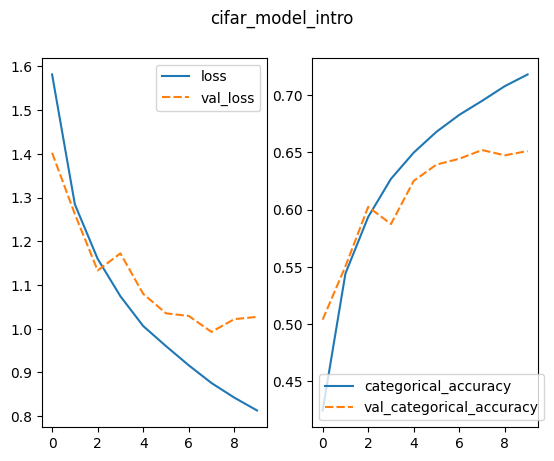

In [9]:
import seaborn as sns
import pandas as pd

# convert the model history to a dataframe for plotting 
history_intro_df = pd.DataFrame.from_dict(history_intro.history)

# plot the loss and accuracy from the training process
fig, axes = plt.subplots(1, 2)
fig.suptitle('cifar_model_intro')
sns.lineplot(ax=axes[0], data=history_intro_df[['loss', 'val_loss']])
sns.lineplot(ax=axes[1], data=history_intro_df[['categorical_accuracy', 'val_categorical_accuracy']])

## CHALLENGE Inspect the Training Curve

Inspect the training curves we have just made and recall the difference between the training and the validation datasets.

1. How does the training progress look?  
- Does the loss increase or decrease?
- What about the accuracy?
- Do either change fast or slowly?
- Do the graphs lines fluctuate or go up and down frequently?  
2. Do you think the resulting trained network will work well on the test set?